In [1]:
!pip install ollama

In [2]:
!sudo apt update && sudo apt install pciutils lshw


Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,482 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,980 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,219 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,960 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd6

In [3]:
!apt-get install -y zstd

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 59 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 0s (1,701 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 122387 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...


In [4]:
!curl -fsSL https://ollama.com/install.sh | sh

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> NVIDIA GPU installed.
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [5]:
import subprocess
import time
def run_ollama_serve():
    subprocess.Popen(["ollama", "serve"])

run_ollama_serve()
time.sleep(5) # Give the server a few seconds to start


In [6]:
!ollama signin

You need to be signed in to Ollama to run Cloud models.

/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening 'https://ollama.com/connect?name=2b9149fb3e49&key=c3NoLWVkMjU1MTkgQUFBQUMzTnphQzFsWkRJMU5URTVBQUFBSUFXOVk5dzgwbkVuOFlmU0xURTVLWGd3RFQ5S2VOZDYwMEp4SERscG9PK2Y'
If your browser did not open, navigate to:
    https://ollama.com/connect?name=2b9149fb3e49&key=c3NoLWVkMjU1MTkgQUFBQUMzTnphQzFsWkRJMU5URTVBQUFBSUFXOVk5dzgwbkVuOFlmU0xURTVLWGd3RFQ5S2VOZDYwMEp4SERscG9PK2Y



## 2. Imports

In [7]:
import os, json, torch
import numpy as np
from tqdm.notebook import tqdm
from ollama import Client
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
print('PyTorch :', torch.__version__)
print('Device  :', 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch : 2.10.0+cu128
Device  : cuda


## 3. Configuration

In [8]:
MODEL_NAME        = "Qwen/Qwen2.5-1.5B-Instruct"
DEVICE            = "cuda" if torch.cuda.is_available() else "cpu"
JUDGE_MODEL       = "gpt-oss:120b-cloud"
NUM_QUERIES       = 100
SAMPLES_PER_QUERY = 10
MAX_NEW_TOKENS    = 128
TEMPERATURE       = 0.8
TOP_P             = 0.95
LASSO_C           = 0.01
MAX_ITER          = 1000
OUTPUT_DIR        = "h_neuron_results"
import os; os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Output dir:", OUTPUT_DIR)

Output dir: h_neuron_results


## 4. Initialise Ollama Client

In [9]:
client = Client()
try:
    available = [m.model for m in client.list().models]
    print("Local Ollama models:", available)
    if JUDGE_MODEL not in available:
        print(f"Note: '{JUDGE_MODEL}' not local — will be routed to cloud.")
except Exception as e:
    print("Ollama ping:", e)

Local Ollama models: []
Note: 'gpt-oss:120b-cloud' not local — will be routed to cloud.


## 5. Load Qwen 2.5-1.5B-Instruct

In [10]:
print(f"Loading {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    device_map="auto",
    trust_remote_code=True,
)
model.eval()
NUM_LAYERS        = model.config.num_hidden_layers
HIDDEN_SIZE       = model.config.hidden_size
INTERMEDIATE_SIZE = model.config.intermediate_size
print(f"  Layers      : {NUM_LAYERS}")
print(f"  Hidden size : {HIDDEN_SIZE}")
print(f"  MLP size    : {INTERMEDIATE_SIZE}")

Loading Qwen/Qwen2.5-1.5B-Instruct ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

  Layers      : 28
  Hidden size : 1536
  MLP size    : 8960


## 6. Ollama Judge Functions

Uses the same prompt structure and `<hallucination>` tag parsing as your evaluation code.

In [11]:
def judge_prompt(model_output, correct_output):
    return (
        "<prompt>\n"
        "You are an expert evaluator tasked with determining whether a language model's\n"
        "output contains hallucinations. A hallucination occurs when the model generates\n"
        "information that is factually incorrect, fabricated, or not supported by the\n"
        "correct output.\n\n"
        "<input>\n"
        "<model_output>\n"
        f"{model_output}\n"
        "</model_output>\n"
        "<correct_output>\n"
        f"{correct_output}\n"
        "</correct_output>\n"
        "</input>\n\n"
        "Compare the model output against the correct output. Determine if it contains:\n"
        "- Factually incorrect information\n"
        "- Fabricated details not present in the correct output\n"
        "- Contradictions to the correct output\n\n"
        "Note: Paraphrasing, different wording, or omissions are NOT hallucinations.\n\n"
        "Respond with only:\n"
        "- 0 if there is NO hallucination\n"
        "- 1 if there IS a hallucination\n\n"
        "<hallucination>{0 or 1}</hallucination>\n"
        "</prompt>"
    )

def judge_correctness(question, gold_aliases, response):
    correct = gold_aliases[0] if gold_aliases else ""
    prompt  = judge_prompt(model_output=response, correct_output=correct)
    result  = client.chat(
        model=JUDGE_MODEL,
        messages=[{"role": "user", "content": prompt}]
    )
    content = result.message.content
    try:
        label = int(content.split("<hallucination>")[1].split("</hallucination>")[0].strip())
    except (IndexError, ValueError):
        label = 1 if "1" in content else 0
    return label == 0   # True = correct (no hallucination)

def span_prompt(question, response):
    return (
        "<prompt>\n"
        "You are a precise text extractor.\n\n"
        "<input>\n"
        f"<question>{question}</question>\n"
        f"<response>{response}</response>\n"
        "</input>\n\n"
        "Extract and return only the exact substring from the response that contains\n"
        "the factual answer to the question. No punctuation, no explanation.\n\n"
        "<answer_span>{exact substring}</answer_span>\n"
        "</prompt>"
    )

def extract_answer_span(question, response):
    result  = client.chat(
        model=JUDGE_MODEL,
        messages=[{"role": "user", "content": span_prompt(question, response)}]
    )
    content = result.message.content
    try:
        return content.split("<answer_span>")[1].split("</answer_span>")[0].strip()
    except IndexError:
        return response[:80]

print("Ollama judge functions defined.")

Ollama judge functions defined.


## 7. Generation Helpers

In [12]:
def build_prompt(question):
    messages = [
        {"role": "system", "content": "Answer the following question concisely and factually."},
        {"role": "user",   "content": question},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def sample_responses(prompt, k):
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    responses = []
    with torch.no_grad():
        for _ in range(k):
            output  = model.generate(
                **inputs, max_new_tokens=MAX_NEW_TOKENS,
                do_sample=True, temperature=TEMPERATURE, top_p=TOP_P,
                pad_token_id=tokenizer.eos_token_id,
            )
            gen_ids = output[0][inputs["input_ids"].shape[-1]:]
            responses.append(tokenizer.decode(gen_ids, skip_special_tokens=True).strip())
    return responses

print("Generation helpers defined.")

Generation helpers defined.


## 8. Sample Responses & Consistency Filter
Longest step. Checkpointed every 10 queries.

In [13]:
print("Loading TriviaQA ...")
triviaqa = load_dataset("trivia_qa", "rc.nocontext", split="validation")
triviaqa = triviaqa.select(range(NUM_QUERIES))

consistent_examples = []

for i, item in enumerate(tqdm(triviaqa, desc="Sampling & filtering")):
    question     = item["question"]
    gold_aliases = item["answer"]["aliases"]
    prompt       = build_prompt(question)
    responses    = sample_responses(prompt, SAMPLES_PER_QUERY)
    correctness  = [judge_correctness(question, gold_aliases, r) for r in responses]
    n_correct    = sum(correctness)

    if n_correct == SAMPLES_PER_QUERY:
        for r in responses:
            consistent_examples.append({"prompt": prompt, "response": r, "label": 0, "question": question})
    elif n_correct == 0:
        for r in responses:
            consistent_examples.append({"prompt": prompt, "response": r, "label": 1, "question": question})

    if (i + 1) % 10 == 0:
        print(f"  [{i+1}/{NUM_QUERIES}]  kept: {len(consistent_examples)}")

n_hall  = sum(e["label"] == 1 for e in consistent_examples)
n_faith = sum(e["label"] == 0 for e in consistent_examples)
print(f"Retained {len(consistent_examples)} — Hallucinatory: {n_hall}  Faithful: {n_faith}")
with open(f"{OUTPUT_DIR}/consistent_examples.json", "w") as f:
    json.dump(consistent_examples, f, indent=2)
print("Checkpoint saved.")

Loading TriviaQA ...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

rc.nocontext/train-00000-of-00001.parque(…):   0%|          | 0.00/55.4M [00:00<?, ?B/s]

rc.nocontext/validation-00000-of-00001.p(…):   0%|          | 0.00/7.34M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/138384 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/17944 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/17210 [00:00<?, ? examples/s]

Sampling & filtering:   0%|          | 0/100 [00:00<?, ?it/s]

  [10/100]  kept: 90
  [20/100]  kept: 150
  [30/100]  kept: 230
  [40/100]  kept: 290
  [50/100]  kept: 360
  [60/100]  kept: 440
  [70/100]  kept: 520
  [80/100]  kept: 610
  [90/100]  kept: 690
  [100/100]  kept: 790
Retained 790 — Hallucinatory: 780  Faithful: 10
Checkpoint saved.


## 9. Extract Answer Token Spans

In [14]:
for ex in tqdm(consistent_examples, desc="Answer spans"):
    ex["answer_span"] = extract_answer_span(ex["question"], ex["response"])

print("Sample spans:")
for ex in consistent_examples[:3]:
    print(f"  Q   : {ex['question'][:70]}")
    print(f"  Span: {ex['answer_span']}")
    print()

Answer spans:   0%|          | 0/790 [00:00<?, ?it/s]

Sample spans:
  Q   : Who was the man behind The Chipmunks?
  Span: Jerry Stiller

  Q   : Who was the man behind The Chipmunks?
  Span: {Bob Wheeler}

  Q   : Who was the man behind The Chipmunks?
  Span: Jerry Jones



## 10. Compute CETT Features

In [15]:
def get_answer_token_mask(full_text, answer_span, input_ids):
    tokens     = [tokenizer.decode([tid]) for tid in input_ids[0]]
    span_lower = answer_span.lower()
    mask       = torch.zeros(len(tokens), dtype=torch.bool)
    for start in range(len(tokens)):
        for end in range(start + 1, min(start + 30, len(tokens) + 1)):
            window = "".join(tokens[start:end]).strip().lower()
            if span_lower in window or window in span_lower:
                mask[start:end] = True
                break
    return mask

class MlpNeuronHook:
    def __init__(self):
        self.activations = {}
    def hook_fn(self, layer_idx):
        def _hook(module, input, output):
            self.activations[layer_idx] = output.detach().float().squeeze(0)
        return _hook

def compute_cett(example):
    full_text  = example["prompt"] + example["response"]
    inputs     = tokenizer(full_text, return_tensors="pt").to(DEVICE)
    ans_mask   = get_answer_token_mask(full_text, example["answer_span"], inputs["input_ids"]).to(DEVICE)
    other_mask = ~ans_mask

    hook_store = MlpNeuronHook()
    hooks = []
    for layer_idx, layer in enumerate(model.model.layers):
        hooks.append(layer.mlp.act_fn.register_forward_hook(hook_store.hook_fn(layer_idx)))

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    for h in hooks: h.remove()

    cett_answer = np.zeros((NUM_LAYERS, INTERMEDIATE_SIZE), dtype=np.float32)
    cett_other  = np.zeros((NUM_LAYERS, INTERMEDIATE_SIZE), dtype=np.float32)

    for layer_idx in range(NUM_LAYERS):
        if layer_idx not in hook_store.activations: continue
        neuron_acts  = hook_store.activations[layer_idx]
        h_total      = outputs.hidden_states[layer_idx + 1].squeeze(0).float()
        h_norm       = torch.norm(h_total, dim=-1, keepdim=True).clamp(min=1e-8)
        W_down       = model.model.layers[layer_idx].mlp.down_proj.weight.float()
        neuron_norms = torch.norm(W_down, dim=0)
        contribs     = (neuron_acts.abs() * neuron_norms.unsqueeze(0)) / h_norm
        if ans_mask.sum() > 0:
            cett_answer[layer_idx] = contribs[ans_mask].mean(0).cpu().detach().numpy()
        if other_mask.sum() > 0:
            cett_other[layer_idx]  = contribs[other_mask].mean(0).cpu().detach().numpy()
    return cett_answer, cett_other

print("Computing CETT features ...")
for ex in tqdm(consistent_examples, desc="CETT"):
    ca, co = compute_cett(ex)
    ex["cett_answer"] = ca
    ex["cett_other"]  = co
print("Done.")

Computing CETT features ...


CETT:   0%|          | 0/790 [00:00<?, ?it/s]

Done.


## 11. Sparse L1 Probing → H-Neurons

Label scheme (Gao et al.):
- **Positive (y=1):** answer-token CETT from hallucinatory responses
- **Negative (y=0):** answer-token CETT from faithful responses + other-token CETT from both

In [16]:
X_rows, y_labels = [], []
for ex in consistent_examples:
    ca   = ex["cett_answer"].flatten()
    co   = ex["cett_other"].flatten()
    feat = np.concatenate([ca, co])
    if ex["label"] == 1:
        X_rows.append(feat);                                     y_labels.append(1)
        X_rows.append(np.concatenate([np.zeros_like(ca), co]));  y_labels.append(0)
    else:
        X_rows.append(feat);                                     y_labels.append(0)

X = np.stack(X_rows).astype(np.float32)
y = np.array(y_labels, dtype=np.int32)
print(f"Feature matrix : {X.shape}  |  Pos: {y.sum()}  Neg: {(y==0).sum()}")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

clf = LogisticRegression(
    penalty="l1", C=LASSO_C, solver="liblinear",
    max_iter=MAX_ITER, class_weight="balanced", random_state=42
)
clf.fit(X_scaled, y)
print(classification_report(y, clf.predict(X_scaled), target_names=["faithful", "hallucinated"]))

Feature matrix : (1570, 501760)  |  Pos: 780  Neg: 790
              precision    recall  f1-score   support

    faithful       1.00      0.99      0.99       790
hallucinated       0.99      1.00      0.99       780

    accuracy                           0.99      1570
   macro avg       0.99      0.99      0.99      1570
weighted avg       0.99      0.99      0.99      1570



## 12. Extract & Inspect H-Neurons

In [17]:
n_half         = NUM_LAYERS * INTERMEDIATE_SIZE
coef_answer_2d = clf.coef_[0][:n_half].reshape(NUM_LAYERS, INTERMEDIATE_SIZE)
h_neuron_mask  = coef_answer_2d > 0
h_neuron_count = int(h_neuron_mask.sum())

print(f"H-Neurons identified : {h_neuron_count}")
print(f"Fraction of total    : {100 * h_neuron_count / (NUM_LAYERS * INTERMEDIATE_SIZE):.4f}%")

h_neurons = sorted([
    {"layer": int(l), "neuron_idx": int(n), "weight": float(coef_answer_2d[l, n])}
    for l in range(NUM_LAYERS) for n in np.where(h_neuron_mask[l])[0]
], key=lambda x: -x["weight"])

print(f"\n{'Layer':>6}  {'Neuron':>8}  {'Weight':>10}")
print("-" * 30)
for e in h_neurons[:20]:
    print(f"{e['layer']:>6}  {e['neuron_idx']:>8}  {e['weight']:>10.4f}")

H-Neurons identified : 125
Fraction of total    : 0.0498%

 Layer    Neuron      Weight
------------------------------
    25      4151      0.7998
    16       968      0.1937
    21      5637      0.1699
     7       616      0.1644
     8      2763      0.1196
     8       685      0.0670
     1      8109      0.0557
    22      7495      0.0532
    15      2453      0.0530
    27      2734      0.0479
     5      8016      0.0397
    21      2563      0.0384
    21      1269      0.0343
    21      5844      0.0299
    25      1399      0.0282
    10      2803      0.0275
    23      1057      0.0252
     1      1837      0.0236
    18      8227      0.0233
    27      8328      0.0230


## 13. Save & Download Results

In [18]:
with open(f"{OUTPUT_DIR}/h_neurons.json", "w") as f:
    json.dump(h_neurons, f, indent=2)
np.save(f"{OUTPUT_DIR}/cett_answer_weights.npy", coef_answer_2d)
np.save(f"{OUTPUT_DIR}/h_neuron_mask.npy",       h_neuron_mask)
print("Saved to", OUTPUT_DIR)
from google.colab import files
files.download(f"{OUTPUT_DIR}/h_neurons.json")

Saved to h_neuron_results


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 14. Visualise H-Neuron Distribution

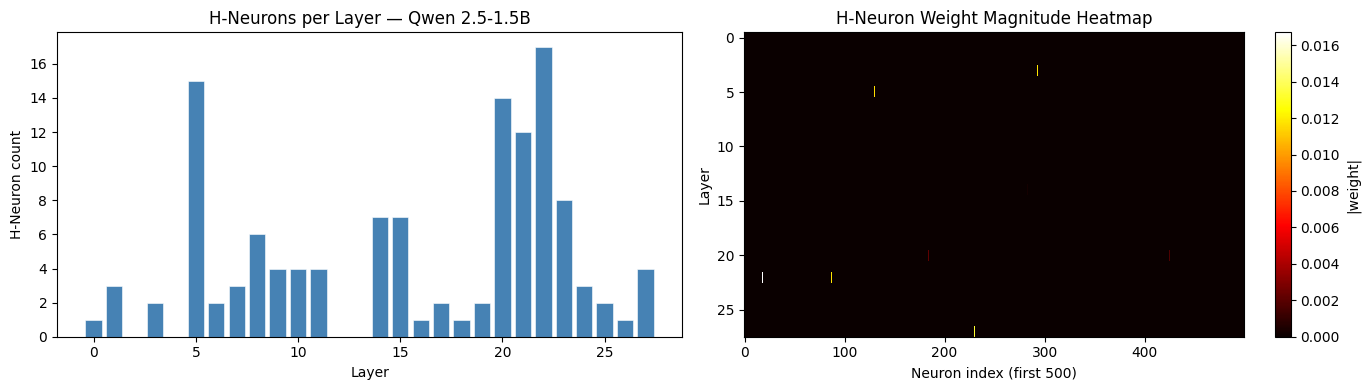

Figure saved.


In [19]:
import matplotlib.pyplot as plt

h_per_layer = h_neuron_mask.sum(axis=1)
fig, axes   = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(NUM_LAYERS), h_per_layer, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("H-Neuron count")
axes[0].set_title("H-Neurons per Layer — Qwen 2.5-1.5B")

sample_cols = min(500, INTERMEDIATE_SIZE)
im = axes[1].imshow(np.abs(coef_answer_2d[:, :sample_cols]),
                    aspect="auto", cmap="hot", interpolation="nearest")
plt.colorbar(im, ax=axes[1], label="|weight|")
axes[1].set_xlabel(f"Neuron index (first {sample_cols})")
axes[1].set_ylabel("Layer")
axes[1].set_title("H-Neuron Weight Magnitude Heatmap")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/h_neuron_distribution.png", dpi=150)
plt.show()
print("Figure saved.")

In [39]:
# ── Remove ALL stale hooks from every MLP layer ──────────────────────────────
for layer in model.model.layers:
    layer.mlp.act_fn._forward_hooks.clear()
    layer.mlp.act_fn._forward_pre_hooks.clear()

print("All stale hooks cleared.")

All stale hooks cleared.


In [40]:
import pandas as pd
CLIP_MODE = "zero"   # "mean" | "second" | "zero"

clip_thresh = second_thresh if CLIP_MODE == "second" else (
              mean_thresh   if CLIP_MODE == "mean"   else None)
print(f"Using clipping mode: {CLIP_MODE}")

class ClipAndCollect:
    def __init__(self, is_hallucination):
        self.is_hallucination = is_hallucination

    def make_mlp_hook(self, layer_idx):
        mask_np   = h_neuron_mask[layer_idx]
        mask_cpu  = torch.from_numpy(mask_np)

        if CLIP_MODE != "zero":
            thresh_np  = clip_thresh[layer_idx][mask_np].copy()
            thresh_cpu = torch.from_numpy(thresh_np)
        else:
            thresh_cpu = None

        def _h(module, inp, out):
            if self.is_hallucination:
                dev, dtype = out.device, out.dtype
                mask    = mask_cpu.to(device=dev)
                clipped = out.clone()

                if CLIP_MODE == "zero":
                    clipped[..., mask] = 0.0
                else:
                    thresh = thresh_cpu.to(device=dev, dtype=dtype)
                    clipped[..., mask] = out[..., mask].clamp(max=thresh)

                return clipped
        return _h

def run_clipped_forward(example):
    full_text  = example["prompt"] + example["response"]
    inputs     = tokenizer(full_text, return_tensors="pt").to(DEVICE)
    controller = ClipAndCollect(example["label"] == 1)
    hooks = [
        layer.mlp.act_fn.register_forward_hook(controller.make_mlp_hook(li))
        for li, layer in enumerate(model.model.layers)
    ]
    try:
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
    finally:
        for h in hooks:
            h.remove()
    return [
        outputs.hidden_states[li+1].squeeze(0).mean(0).cpu().float().numpy()
        for li in range(NUM_LAYERS)
    ]

rows = []
for ex in tqdm(consistent_examples, desc=f"Forward pass [{CLIP_MODE}]"):
    hs  = run_clipped_forward(ex)
    row = {"hallucination_label": ex["label"]}
    for li, h in enumerate(hs):
        row[f"state_{li}"] = h
    rows.append(row)

df_clipped = pd.DataFrame(rows)
print(f"Done — {df_clipped.shape}")
print(f"  Hallucinations: {(df_clipped.hallucination_label==1).sum()}")
print(f"  Faithful:       {(df_clipped.hallucination_label==0).sum()}")

Using clipping mode: zero


Forward pass [zero]:   0%|          | 0/790 [00:00<?, ?it/s]

Done — (790, 29)
  Hallucinations: 780
  Faithful:       10


Layers: 28
Saved: Qwen2.5-1.5B_zero_clipped_zero_layer_analysis.png


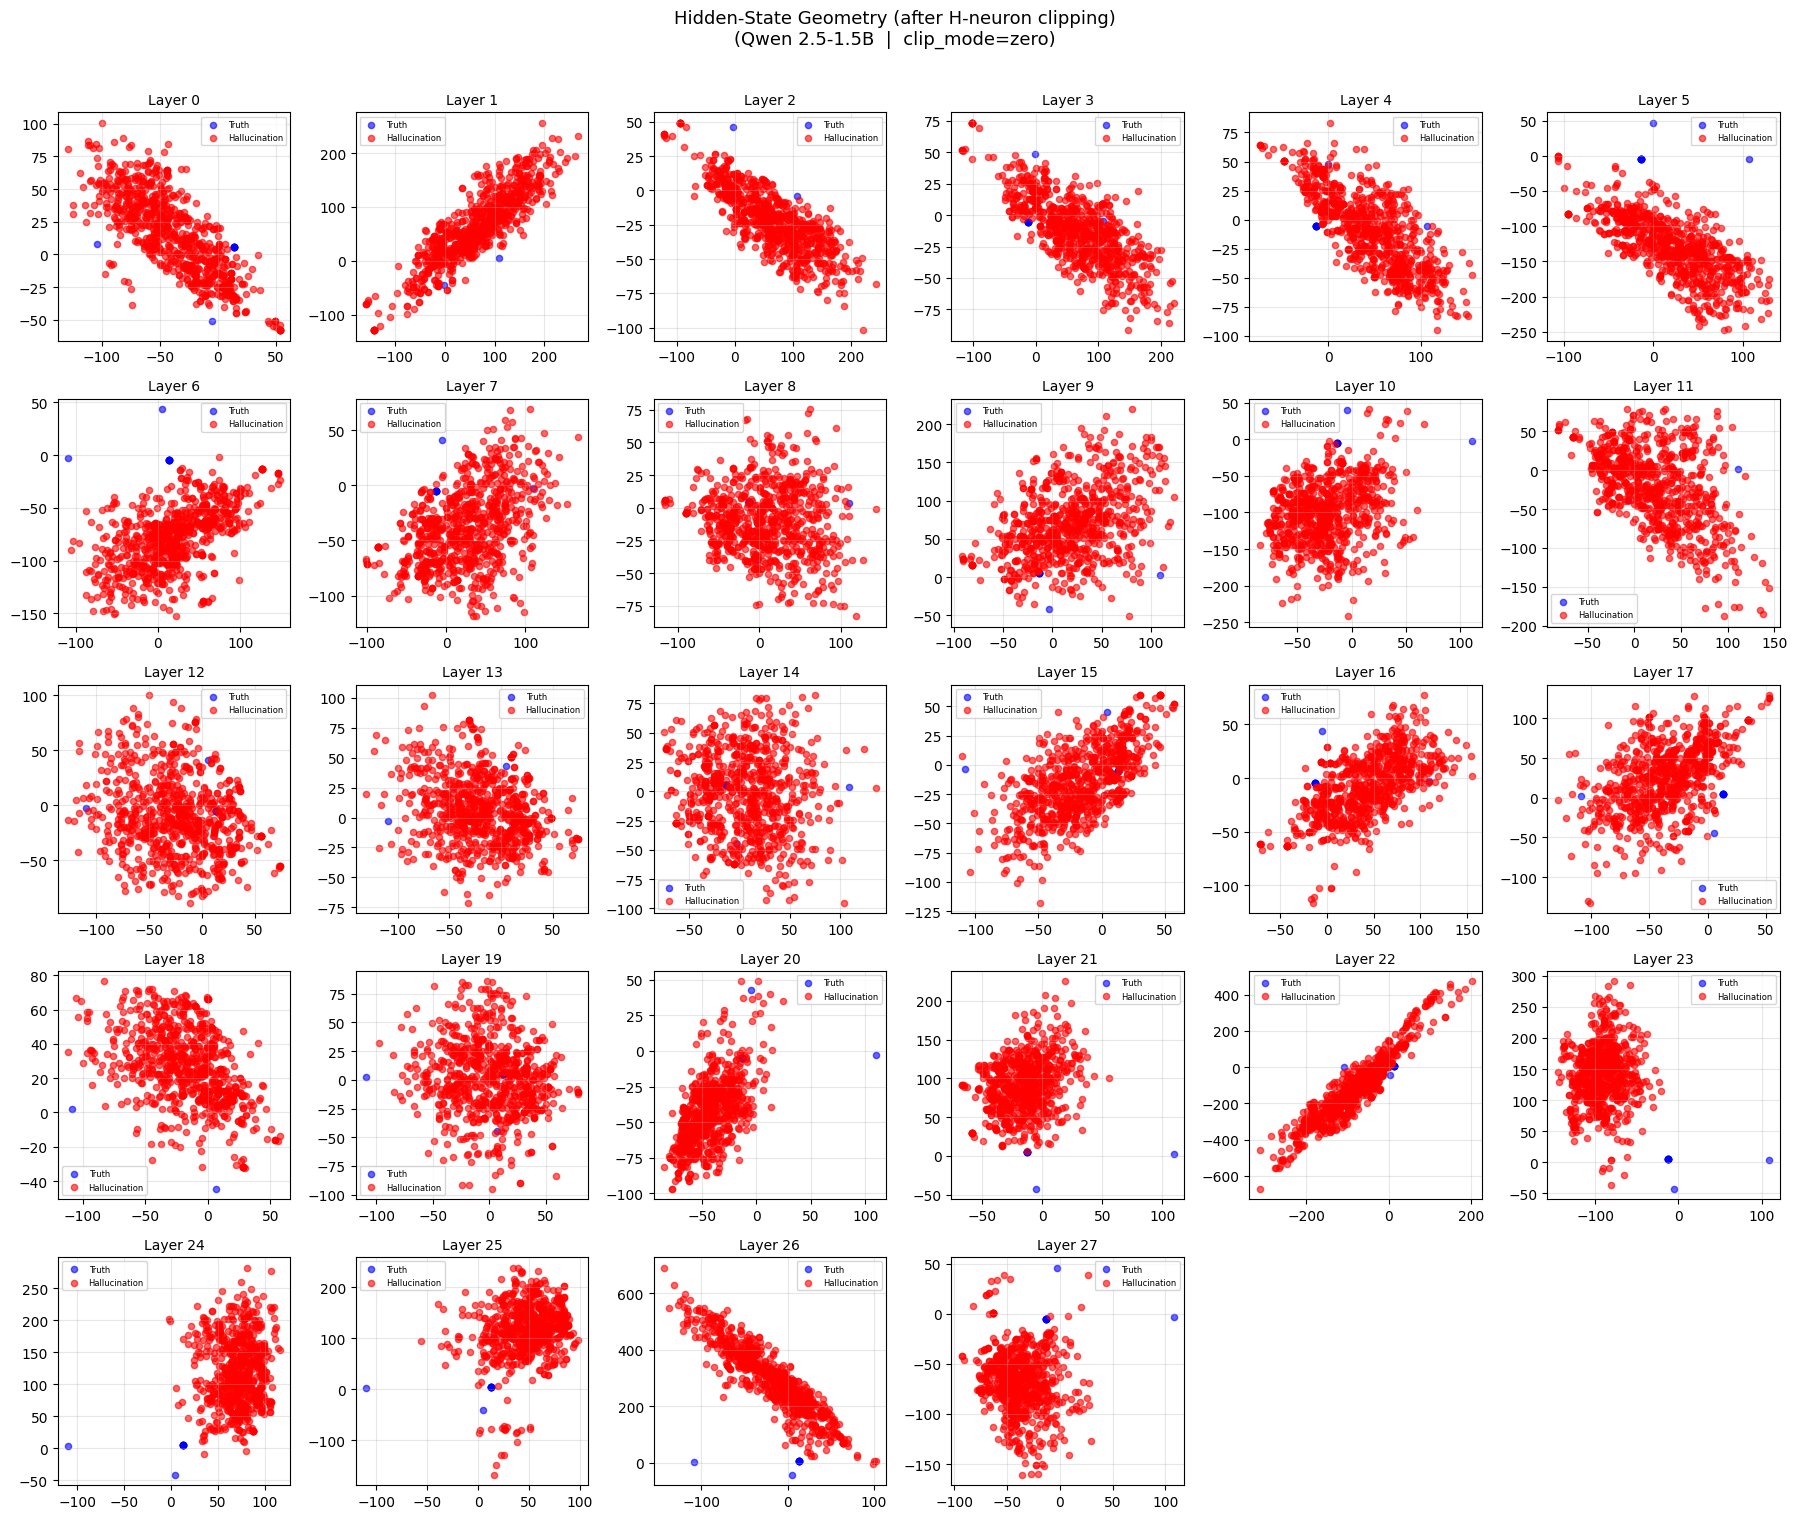

In [41]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import re


def analyzeLayers_clipped(df, title_suffix="(after H-neuron clipping)"):
    state_columns = [c for c in df.columns if c.startswith("state_")]
    n_layers = len(state_columns)

    truths        = []
    hallucinations = []
    for col in state_columns:
        truths.append(df[df["hallucination_label"] == 0][col].values)
        hallucinations.append(df[df["hallucination_label"] == 1][col].values)

    print(f"Layers: {n_layers}")

    n_cols = 6
    n_rows = (n_layers + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
    axes = axes.flatten()

    for i in range(n_layers):
        try:
            # Stack arrays (each is already (hidden_size,) — no padding needed)
            tt = np.stack(truths[i])        # (n_truth, hidden)
            ff = np.stack(hallucinations[i]) # (n_hallu, hidden)

            scaler  = StandardScaler()
            tt_sc   = scaler.fit_transform(tt)
            ff_sc   = scaler.transform(ff)

            pca     = PCA(n_components=2)
            tt_2d   = pca.fit_transform(tt_sc)
            ff_2d   = pca.transform(ff_sc)

            axes[i].scatter(tt_2d[:,0], tt_2d[:,1],
                            color="blue",  label="Truth",        alpha=0.6, s=20)
            axes[i].scatter(ff_2d[:,0], ff_2d[:,1],
                            color="red",   label="Hallucination", alpha=0.6, s=20)
            axes[i].set_title(f"Layer {i}", fontsize=10)
            axes[i].legend(fontsize=6)
            axes[i].grid(True, alpha=0.3)

        except Exception as e:
            axes[i].text(0.5, 0.5, f"Layer {i}\nError: {e}",
                         ha="center", va="center", transform=axes[i].transAxes,
                         fontsize=7)
            axes[i].axis("off")

    for i in range(n_layers, len(axes)):
        axes[i].axis("off")

    fig.suptitle(
        f"Hidden-State Geometry {title_suffix}\n"
        f"(Qwen 2.5-1.5B  |  clip_mode={CLIP_MODE})",
        fontsize=13, y=1.01
    )
    plt.tight_layout()

    out_name = f"Qwen2.5-1.5B_zero_clipped_{CLIP_MODE}_layer_analysis.png"
    plt.savefig(out_name, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_name}")
    plt.show()


analyzeLayers_clipped(df_clipped)

In [42]:
# ═══════════════════════════════════════════════════════════════
# STEP A — Clear any stale hooks
# ═══════════════════════════════════════════════════════════════
for layer in model.model.layers:
    layer.mlp.act_fn._forward_hooks.clear()
    layer.mlp.act_fn._forward_pre_hooks.clear()
print("Hooks cleared.")

Hooks cleared.


In [44]:
# ═══════════════════════════════════════════════════════════════
# STEP B — Re-generate with H-neurons zeroed during generation
# ═══════════════════════════════════════════════════════════════

class ZeroHNeurons:
    """Zeros H-neuron activations in every MLP layer during generation."""
    def make_hook(self, layer_idx):
        mask_cpu = torch.from_numpy(h_neuron_mask[layer_idx])
        def _h(module, inp, out):
            mask = mask_cpu.to(device=out.device)
            out[..., mask] = 0.0
            return out
        return _h

def generate_zeroed(prompt: str) -> str:
    """Generate a response with H-neurons zeroed throughout."""
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    controller = ZeroHNeurons()
    hooks = [
        layer.mlp.act_fn.register_forward_hook(controller.make_hook(li))
        for li, layer in enumerate(model.model.layers)
    ]
    try:
        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
    finally:
        for h in hooks:
            h.remove()
    gen_ids = output[0][inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(gen_ids, skip_special_tokens=True).strip()


print("Generating zeroed responses ...")
# Get one unique prompt per question
unique_questions = {}
for ex in consistent_examples:
    q = ex["question"]
    if q not in unique_questions:
        unique_questions[q] = ex   # store one example per question

unique_examples = list(unique_questions.values())
print(f"Unique questions: {len(unique_examples)}")  # should be ~100

# Generate one zeroed response per question
print("Generating zeroed responses ...")
zeroed_examples = []
for ex in tqdm(unique_examples, desc="Generating [H=0]"):
    new_response = generate_zeroed(ex["prompt"])
    zeroed_examples.append({
        "prompt":         ex["prompt"],
        "response":       new_response,
        "question":       ex["question"],
        "original_label": ex["label"],
    })

print(f"Generated {len(zeroed_examples)} responses.")
print(f"Generated {len(zeroed_examples)} responses.")
print("Sample (first example):")
print("  Original :", consistent_examples[0]["response"][:100])
print("  Zeroed   :", zeroed_examples[0]["response"][:100])

Generating zeroed responses ...
Unique questions: 79
Generating zeroed responses ...


Generating [H=0]:   0%|          | 0/79 [00:00<?, ?it/s]

Generated 79 responses.
Generated 79 responses.
Sample (first example):
  Original : Jerry Stiller created and starred in "The Chipmunks" in 1961.
  Zeroed   : Jerry Giraldi, also known as Jerry Morgenstern, was the creator of The Chipmunks.


In [47]:
import subprocess
import time
def run_ollama_serve():
    subprocess.Popen(["ollama", "serve"])

run_ollama_serve()
time.sleep(5) # Give the server a few seconds to start


In [48]:
!ollama signin

You are already signed in as user 'aalekhbukhariya'



In [49]:
# ═══════════════════════════════════════════════════════════════
# STEP C — Judge new responses with Ollama
# ═══════════════════════════════════════════════════════════════

def judge_response(question: str, response: str) -> int:
    """Returns 1 if hallucinated, 0 if correct."""
    prompt = (
        "<prompt>\n"
        "You are an expert evaluator tasked with determining whether a language model's "
        "output contains hallucinations.\n\n"
        "<input>\n"
        f"<question>{question}</question>\n"
        f"<model_output>{response}</model_output>\n"
        "</input>\n\n"
        "Does the model output correctly and factually answer the question?\n"
        "Respond with only:\n"
        "- 0 if there is NO hallucination\n"
        "- 1 if there IS a hallucination\n\n"
        "<hallucination>{0 or 1}</hallucination>\n"
        "</prompt>"
    )
    result  = client.chat(
        model=JUDGE_MODEL,
        messages=[{"role": "user", "content": prompt}]
    )
    content = result.message.content
    try:
        label = int(content.split("<hallucination>")[1].split("</hallucination>")[0].strip())
    except (IndexError, ValueError):
        label = 1 if "1" in content else 0
    return label


print("Judging zeroed responses ...")
for i, ex in enumerate(tqdm(zeroed_examples, desc="Judging [H=0]")):
    ex["hallucination_label"] = judge_response(ex["question"], ex["response"])
    if (i + 1) % 50 == 0:
        n_hall = sum(e["hallucination_label"] for e in zeroed_examples if "hallucination_label" in e)
        print(f"  [{i+1}/{len(zeroed_examples)}]  hallucinations so far: {n_hall}")

n_hall  = sum(e["hallucination_label"] == 1 for e in zeroed_examples)
n_faith = sum(e["hallucination_label"] == 0 for e in zeroed_examples)
print(f"\nOriginal  — hallucinatory: {sum(e['label']==1 for e in consistent_examples)}  faithful: {sum(e['label']==0 for e in consistent_examples)}")
print(f"Zeroed    — hallucinatory: {n_hall}  faithful: {n_faith}")

Judging zeroed responses ...


Judging [H=0]:   0%|          | 0/79 [00:00<?, ?it/s]

  [50/79]  hallucinations so far: 45

Original  — hallucinatory: 780  faithful: 10
Zeroed    — hallucinatory: 71  faithful: 8


In [50]:
# ═══════════════════════════════════════════════════════════════
# STEP D — Collect hidden states from new responses (clean forward pass)
# ═══════════════════════════════════════════════════════════════

def get_hidden_states(example: dict) -> list:
    """Clean forward pass — no hooks — on the zeroed response."""
    full_text = example["prompt"] + example["response"]
    inputs    = tokenizer(full_text, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    return [
        outputs.hidden_states[li+1].squeeze(0).mean(0).cpu().float().numpy()
        for li in range(NUM_LAYERS)
    ]


print("Collecting hidden states ...")
rows = []
for ex in tqdm(zeroed_examples, desc="Hidden states [H=0]"):
    hs  = get_hidden_states(ex)
    row = {"hallucination_label": ex["hallucination_label"]}
    for li, h in enumerate(hs):
        row[f"state_{li}"] = h
    rows.append(row)

df_zeroed = pd.DataFrame(rows)
print(f"Done — {df_zeroed.shape}")
print(f"  Hallucinations: {(df_zeroed.hallucination_label==1).sum()}")
print(f"  Faithful:       {(df_zeroed.hallucination_label==0).sum()}")

Hidden states [H=0]:   0%|          | 0/79 [00:00<?, ?it/s]

Done — (79, 29)
  Hallucinations: 71
  Faithful:       8


Saved: Qwen2.5-1.5B_H_zeroed_layer_analysis.png


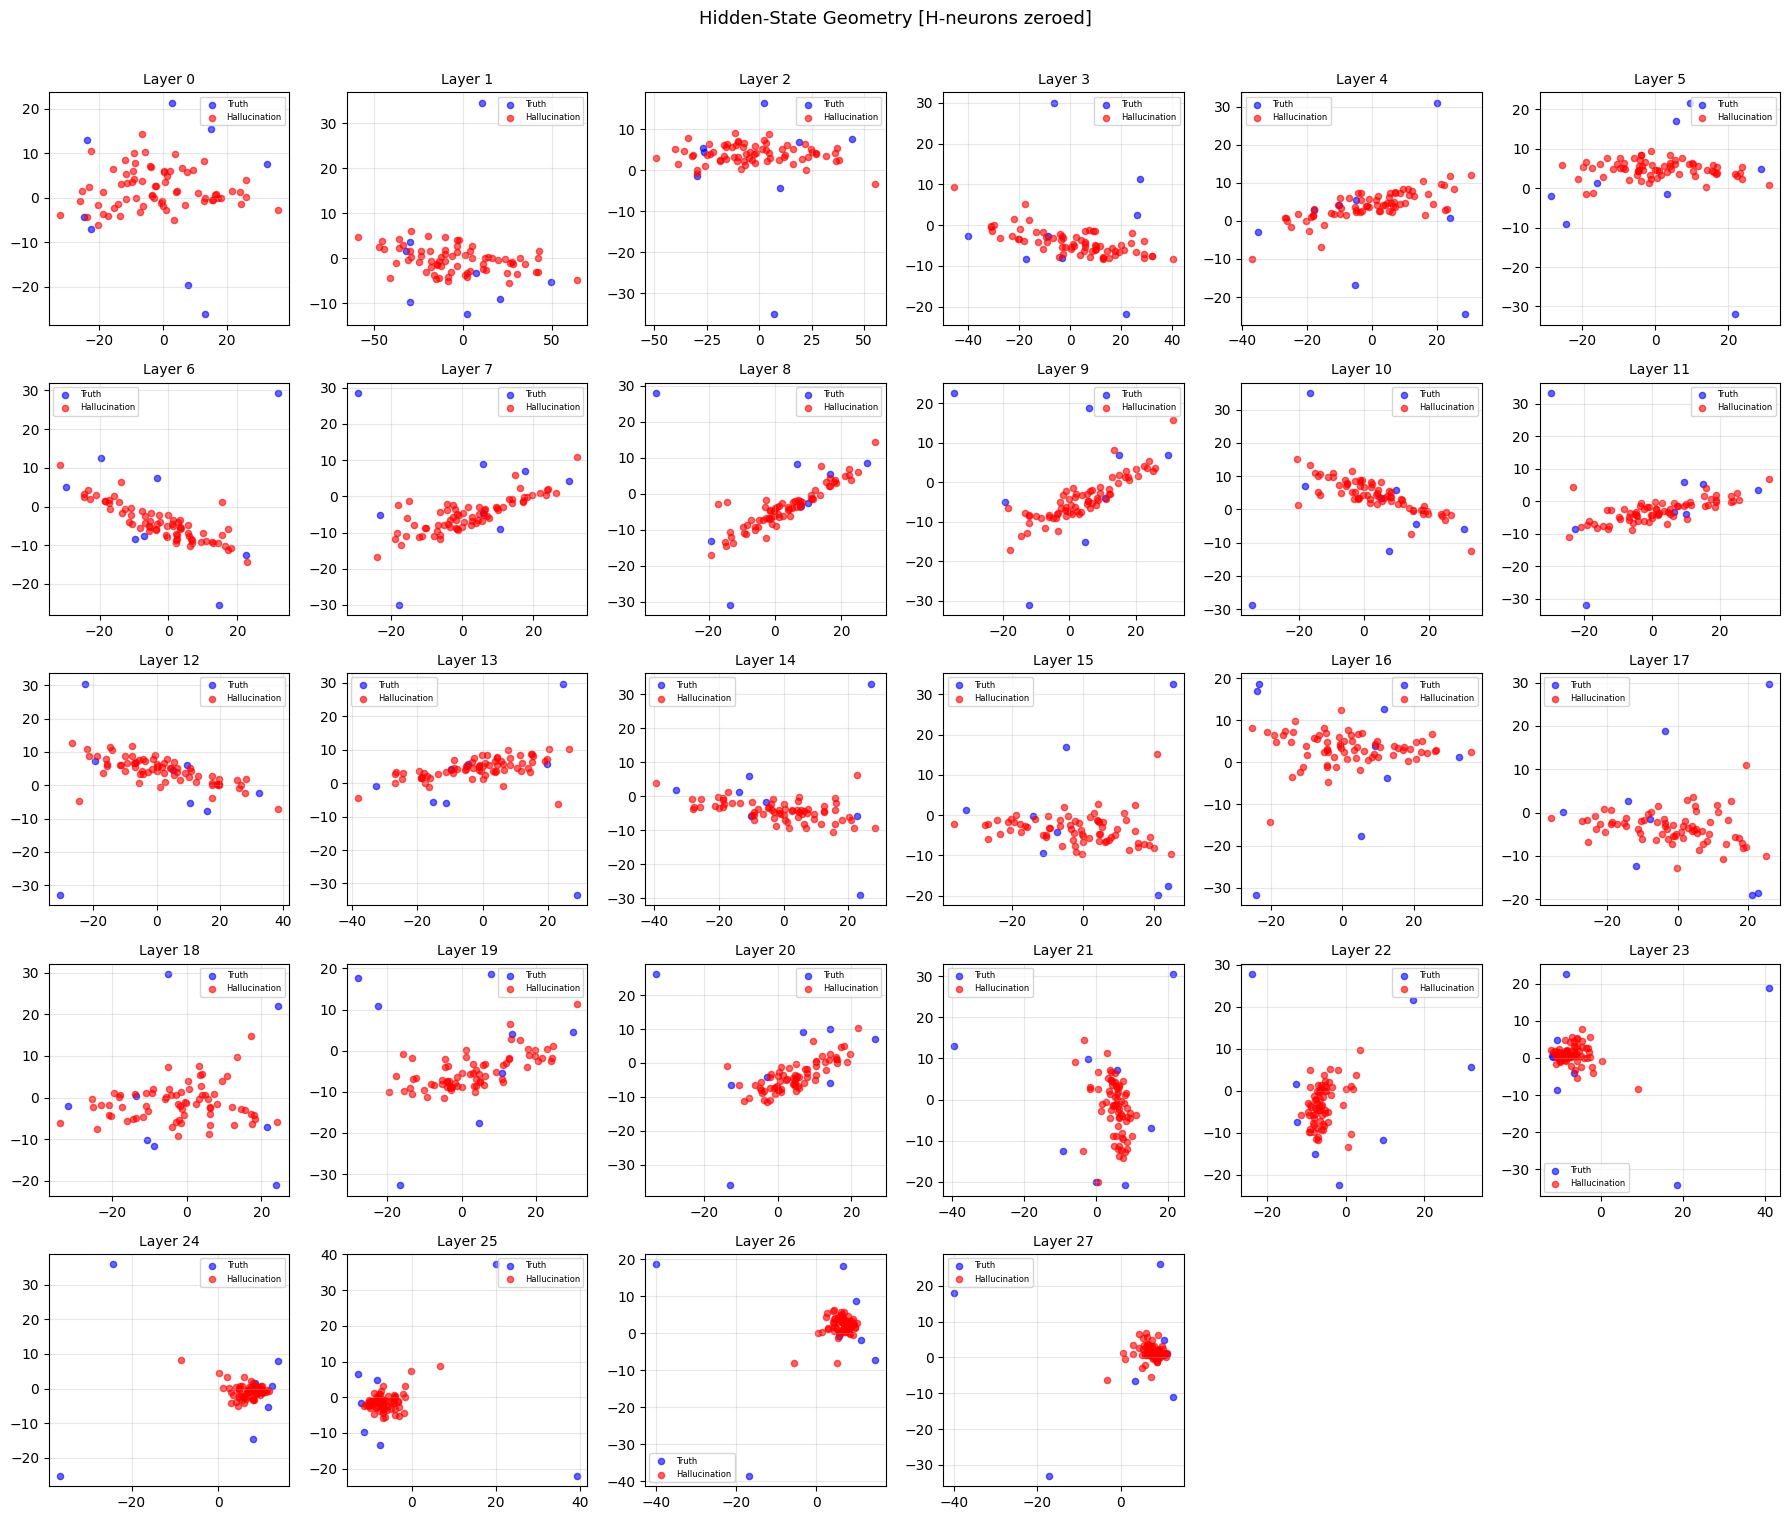

In [51]:
# ═══════════════════════════════════════════════════════════════
# STEP E — Plot (same analyzeLayers logic as original)
# ═══════════════════════════════════════════════════════════════
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

def analyzeLayers_zeroed(df, title="Hidden-State Geometry [H-neurons zeroed]"):
    state_cols = [c for c in df.columns if c.startswith("state_")]
    n_layers   = len(state_cols)
    n_cols     = 6
    n_rows     = (n_layers + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(state_cols):
        try:
            tt = np.stack(df[df["hallucination_label"]==0][col].values)
            ff = np.stack(df[df["hallucination_label"]==1][col].values)

            scaler = StandardScaler()
            tt_sc  = scaler.fit_transform(tt)
            ff_sc  = scaler.transform(ff)

            pca    = PCA(n_components=2)
            tt_2d  = pca.fit_transform(tt_sc)
            ff_2d  = pca.transform(ff_sc)

            axes[i].scatter(tt_2d[:,0], tt_2d[:,1], c="blue", label="Truth",
                            alpha=0.6, s=20)
            axes[i].scatter(ff_2d[:,0], ff_2d[:,1], c="red",  label="Hallucination",
                            alpha=0.6, s=20)
            axes[i].set_title(f"Layer {i}", fontsize=10)
            axes[i].legend(fontsize=6)
            axes[i].grid(True, alpha=0.3)
        except Exception as e:
            axes[i].text(0.5, 0.5, f"Layer {i}\n{e}", ha="center", va="center",
                         transform=axes[i].transAxes, fontsize=7)
            axes[i].axis("off")

    for i in range(n_layers, len(axes)):
        axes[i].axis("off")

    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    fname = "Qwen2.5-1.5B_H_zeroed_layer_analysis.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"Saved: {fname}")
    plt.show()

analyzeLayers_zeroed(df_zeroed)